In [31]:
import pandas as pd

admissions = pd.read_csv('E:/mimic-iv/hosp/admissions.csv.gz')
patients = pd.read_csv('E:/mimic-iv/hosp/patients.csv.gz')
icustays = pd.read_csv('E:/mimic-iv/icu/icustays.csv.gz')

print("admissions:", admissions.shape)
print("patients:", patients.shape)
print("icustays:", icustays.shape)


admissions: (546028, 16)
patients: (364627, 6)
icustays: (94458, 8)


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

Was expecting a 1:1:1 ratio between the rows in the columns (i.e: one patient per column but that's clearly not the case)

In [3]:
from IPython.display import display

tables = ["admissions", "patients", "icustays"]


for table in tables:
    df = eval(table)
    print(f"{table} table:")
    display(df.head())

admissions table:


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


patients table:


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


icustays table:


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


Join key: subject_id column

**Goal**

* Predict LOS (length of stay in days)
* Readmission risk (Bern: Will they come back in 30 days? Probability?)

los column is given to us in icustays table:

but what is the unit of time? I am taking an educated guess that it is in days

Plot los to get an idea of distribution type

## Dataset Column Reference

### `admissions` table
- **subject_id**: Unique patient identifier (links to `patients` table)
- **hadm_id**: Unique hospital admission identifier (one patient can have multiple admissions)
- **admittime**: Date/time the patient was admitted to the hospital
- **dischtime**: Date/time the patient was discharged from the hospital
- **deathtime**: Date/time of death, if the patient died during this admission (NaN otherwise)
- **admission_type**: Category of admission (e.g. URGENT, EW EMER., ELECTIVE) — describes how/why the patient was admitted
- **admit_provider_id**: Identifier for the provider who admitted the patient
- **admission_location**: Where the patient was admitted from (e.g. EMERGENCY ROOM, TRANSFER FROM HOSPITAL)
- **discharge_location**: Where the patient was discharged to (e.g. HOME, HOSPICE)
- **insurance**: Patient's insurance type at time of admission (e.g. Medicaid, Medicare, Private)
- **language**: Patient's primary language
- **marital_status**: Patient's marital status (e.g. WIDOWED, SINGLE, MARRIED)
- **race**: Patient's recorded race/ethnicity (raw MIMIC categories — often 30+ distinct values)
- **edregtime**: Date/time the patient registered in the Emergency Department (if applicable)
- **edouttime**: Date/time the patient left the Emergency Department (if applicable)
- **hospital_expire_flag**: Binary flag — 1 if the patient died during this hospital admission, 0 otherwise

### `patients` table
- **subject_id**: Unique patient identifier (links to `admissions` and `icustays`)
- **gender**: Patient's recorded sex (M/F)
- **anchor_age**: Patient's age during `anchor_year` (not necessarily their age at any given admission — ages are de-identified/shifted)
- **anchor_year**: A de-identified reference year tied to `anchor_age`, used to calculate real elapsed time between events without revealing true calendar dates
- **anchor_year_group**: A 3-year range (e.g. "2014 - 2016") indicating roughly when `anchor_year` fell, for context without exact dates
- **dod**: Date of death, if known (NaN if patient is not recorded as deceased)

### `icustays` table
- **subject_id**: Unique patient identifier
- **hadm_id**: Hospital admission identifier this ICU stay belongs to
- **stay_id**: Unique identifier for this specific ICU stay (a patient can have multiple ICU stays per admission)
- **first_careunit**: ICU unit type the patient was first admitted to (e.g. MICU, SICU)
- **last_careunit**: ICU unit type the patient was in when the stay ended (may differ from `first_careunit` if transferred between ICU types)
- **intime**: Date/time the patient entered this ICU stay
- **outtime**: Date/time the patient left this ICU stay
- **los**: Length of stay in the ICU, in days (target variable for prediction)

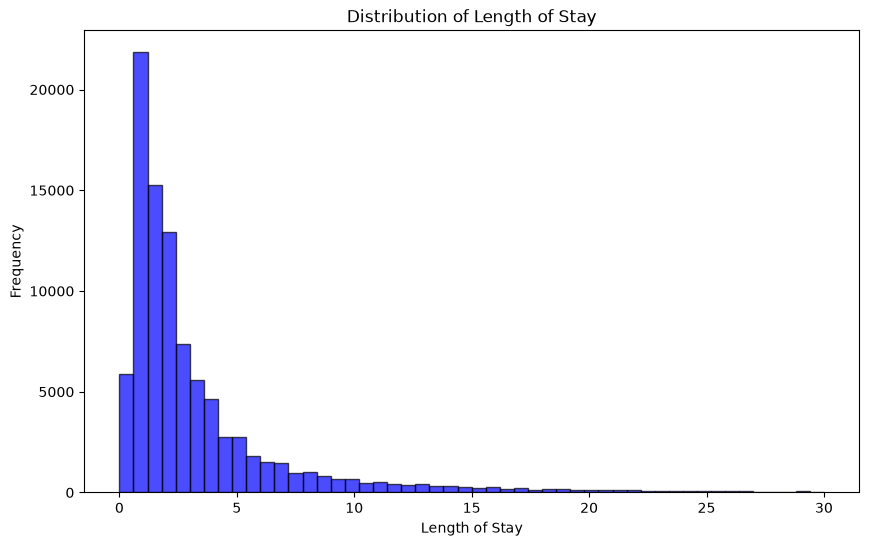

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(icustays['los'], bins=50, color='blue', alpha=0.7, edgecolor='black', range=(0, 30))
plt.xlabel('Length of Stay')
plt.ylabel('Frequency')
plt.title('Distribution of Length of Stay')
plt.show()

LOS looks like it follows an exponential distribution.

In [ ]:
icustays['los'].describe()

# E(X): 3.63
# STD: 5.4
# Rate: 1/3.63 = 0.275

count    94444.000000
mean         3.630025
std          5.402474
min          0.001250
25%          1.096212
50%          1.965648
75%          3.862575
max        226.403079
Name: los, dtype: float64

In [2]:
icustays.head(1)

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266


In [15]:
df = icustays.merge(admissions, on=['subject_id', 'hadm_id'], how='inner')
df = df.merge(patients, on='subject_id', how='inner')

df.shape
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,...,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016,2180-09-09
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,...,WIDOWED,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0,F,86,2150,2008 - 2010,2152-01-30
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,...,MARRIED,BLACK/AFRICAN AMERICAN,2189-06-27 06:25:00,2189-06-27 08:42:00,0,F,73,2186,2008 - 2010,2193-08-26
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,...,MARRIED,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,F,55,2157,2011 - 2013,NaN
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,...,MARRIED,WHITE,NaN,NaN,0,F,55,2157,2011 - 2013,NaN


In [10]:
df['admittime'] = pd.to_datetime(df['admittime'])
df['age_at_admission'] = df['anchor_age'] + (df['admittime'].dt.year - df['anchor_year'])

In [11]:
df['gender_binary'] = (df['gender'] == 'M').astype(int)

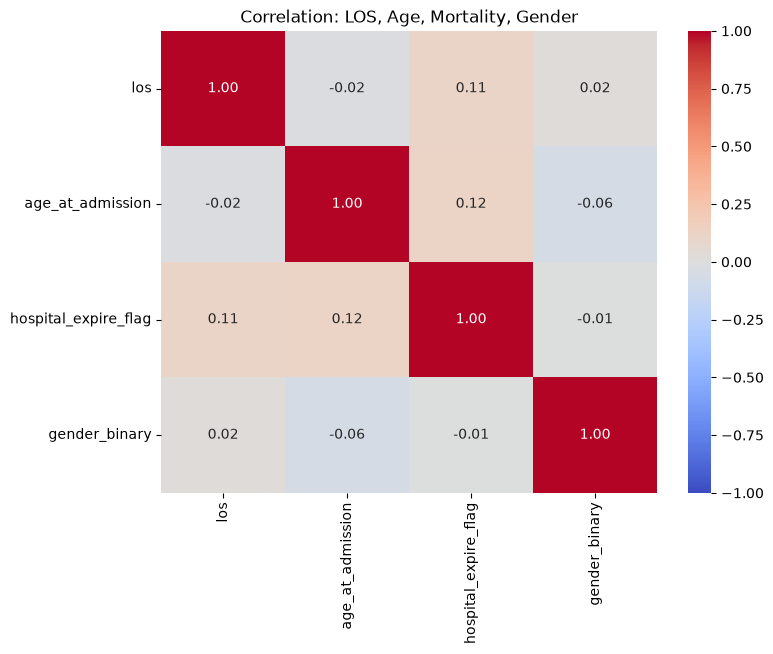

In [12]:
cols_of_interest = ['los', 'age_at_admission', 'hospital_expire_flag', 'gender_binary']
corr = df[cols_of_interest].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation: LOS, Age, Mortality, Gender')
plt.show()

In [17]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod'],
      dtype='str')

How does gender/race play a role in LOS?

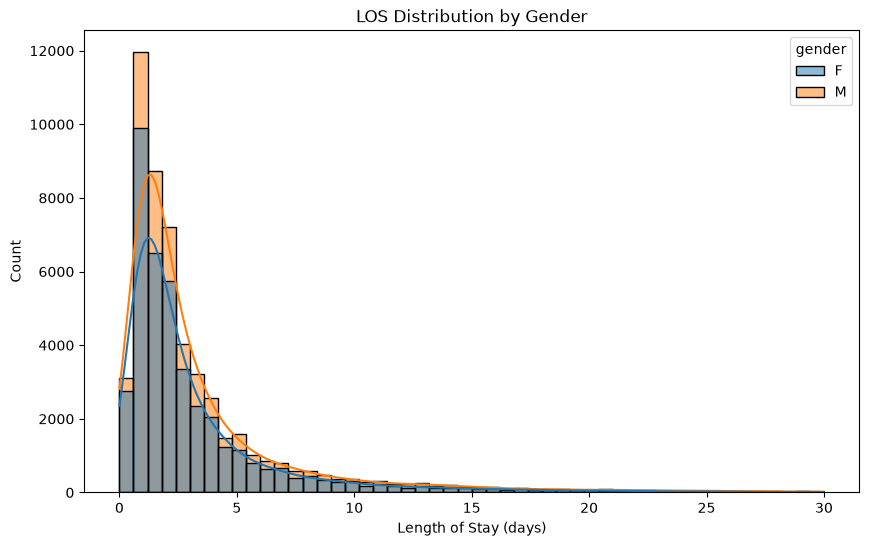

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='los', hue='gender', bins=50, kde=True, alpha=0.5,
             binrange=(0, 30), kde_kws={'clip': (0, 30)})
plt.title('LOS Distribution by Gender')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Count')
plt.show()

In [31]:
df.groupby('gender')['los'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
F,41577.0,3.510167,5.170790,0.001447,1.064109,1.941030,3.793657,159.666806
M,52867.0,3.724286,5.576163,0.001250,1.119201,1.984375,3.920417,226.403079


In [32]:
0.2*24

4.800000000000001

* More males than females (~21k more males)
* On average males LOS is longer by 0.2 days = 4.8 hours
* Males show more variance in LOS (lower min and higher max, potentially skewing the average)

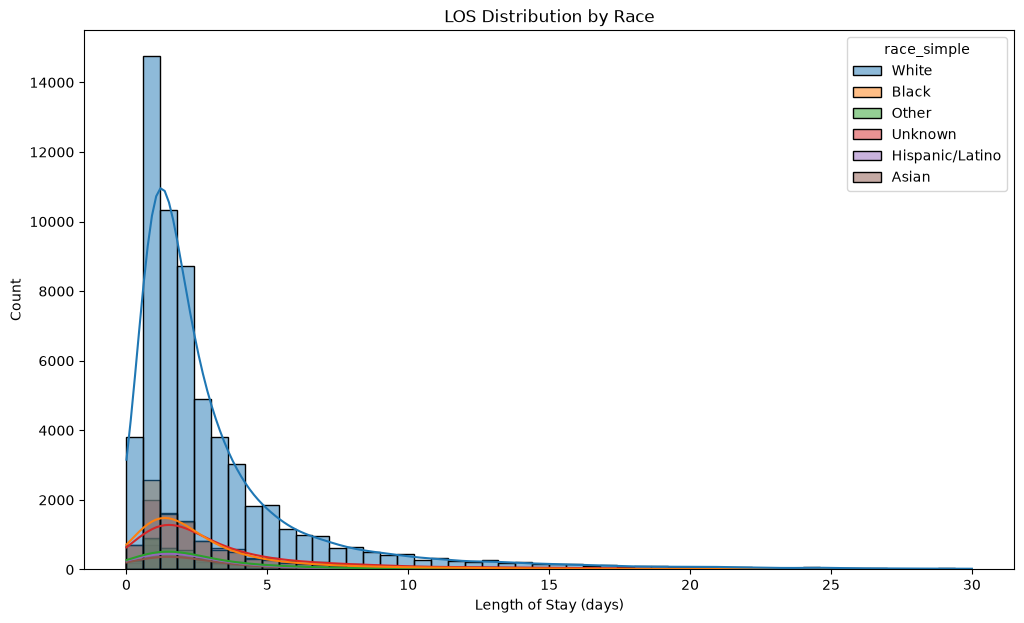

In [26]:
def simplify_race(race):
    race = race.upper()
    if 'WHITE' in race:
        return 'White'
    elif 'BLACK' in race:
        return 'Black'
    elif 'ASIAN' in race:
        return 'Asian'
    elif 'HISPANIC' in race or 'LATINO' in race:
        return 'Hispanic/Latino'
    elif 'UNKNOWN' in race or 'UNABLE' in race or 'DECLINED' in race:
        return 'Unknown'
    else:
        return 'Other'

df['race_simple'] = df['race'].apply(simplify_race)

# check the new distribution
df['race_simple'].value_counts()




plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='los', hue='race_simple', bins=50, kde=True, alpha=0.5,
             binrange=(0, 30), kde_kws={'clip': (0, 30)})
plt.title('LOS Distribution by Race')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Count')
plt.show()

In [35]:
df.groupby('race_simple')['los'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
race_simple,,,,,,,,
Unknown,10848.0,4.494622,6.332754,0.004421,1.203475,2.246649,4.944878,140.053669
Other,4068.0,3.775880,5.518680,0.005984,1.103617,2.005723,4.043770,81.755266
Asian,2885.0,3.622695,5.555758,0.009387,1.070613,1.910787,3.720544,77.740706
Black,10385.0,3.612661,5.603821,0.003461,1.032407,1.908553,3.762755,112.050741
Hispanic/Latino,3595.0,3.561112,5.899492,0.002419,1.076620,1.882222,3.692326,159.666806
White,62663.0,3.478049,5.127958,0.001250,1.094138,1.940949,3.740203,226.403079


Nothing crazy here, let's be more specific then:

In [36]:
df.groupby('race')['los'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
race,,,,,,,,
UNABLE TO OBTAIN,1881.0,4.721309,6.691350,0.004421,1.236111,2.357685,4.970752,86.848403
UNKNOWN,8452.0,4.517706,6.334206,0.014352,1.198692,2.269983,5.032740,140.053669
ASIAN - KOREAN,73.0,4.441330,7.418530,0.211354,1.265845,2.246898,3.903750,41.938299
PORTUGUESE,425.0,4.408925,7.739476,0.054618,1.144120,2.138090,4.205451,81.755266
BLACK/CARIBBEAN ISLAND,621.0,4.342569,6.971010,0.044502,1.107616,2.040150,3.982292,70.689225
AMERICAN INDIAN/ALASKA NATIVE,198.0,4.310959,6.482218,0.087870,1.102248,2.075770,4.714688,49.905231
HISPANIC/LATINO - COLUMBIAN,102.0,4.097819,8.500388,0.353611,1.078310,1.797332,3.808666,73.959120
HISPANIC/LATINO - DOMINICAN,746.0,4.097746,6.307410,0.049201,1.138860,2.131759,4.233325,64.184560
ASIAN - ASIAN INDIAN,248.0,4.079728,7.275491,0.160324,1.094034,1.902627,3.820246,66.267338


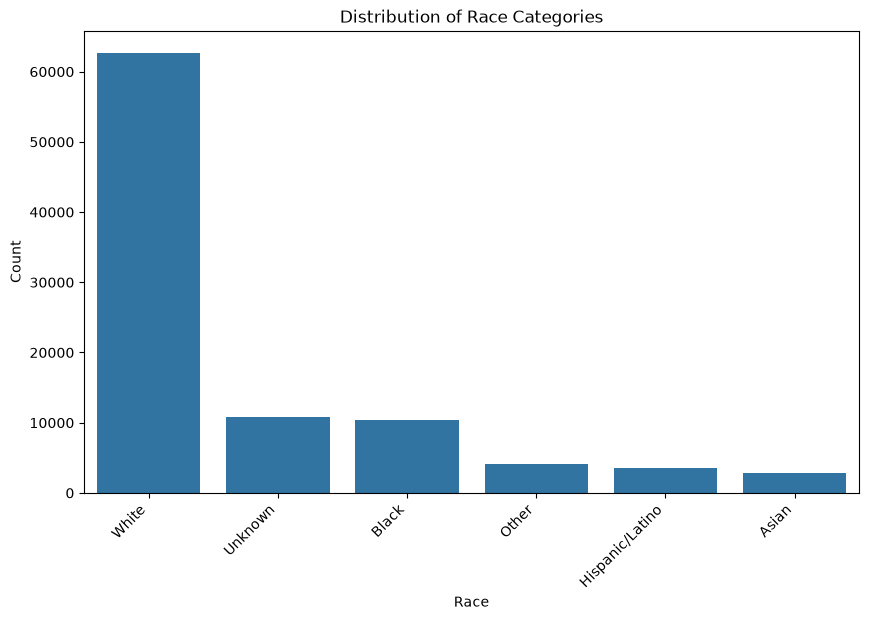

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='race_simple', order=df['race_simple'].value_counts().index)
plt.title('Distribution of Race Categories')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

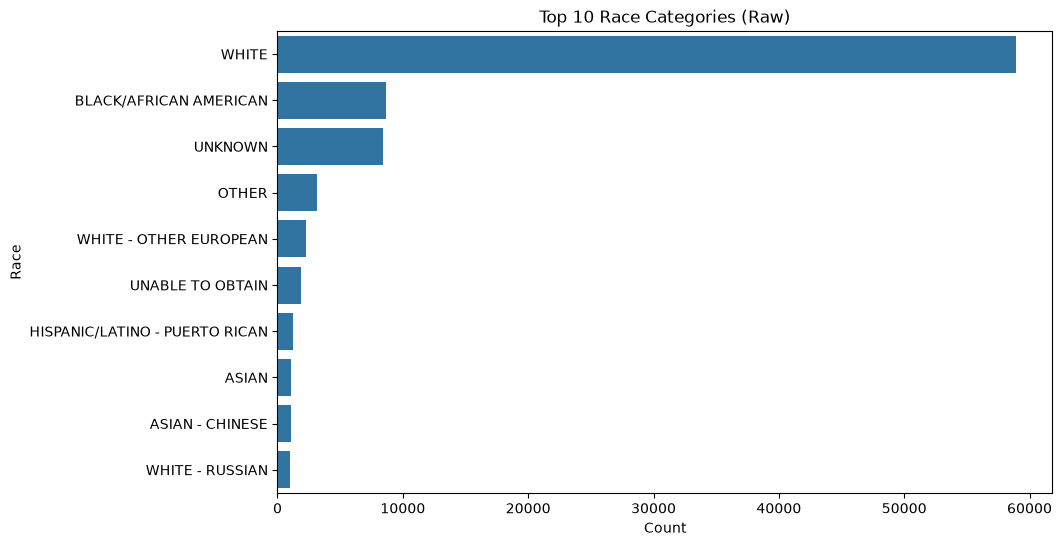

In [42]:
top_races = df['race'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_races.values, y=top_races.index)
plt.title('Top 10 Race Categories (Raw)')
plt.xlabel('Count')
plt.ylabel('Race')
plt.show()

I wonder if marital status plays a role in los:

In [43]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'admit_provider_id', 'admission_location',
       'discharge_location', 'insurance', 'language', 'marital_status', 'race',
       'edregtime', 'edouttime', 'hospital_expire_flag', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'race_simple'],
      dtype='str')

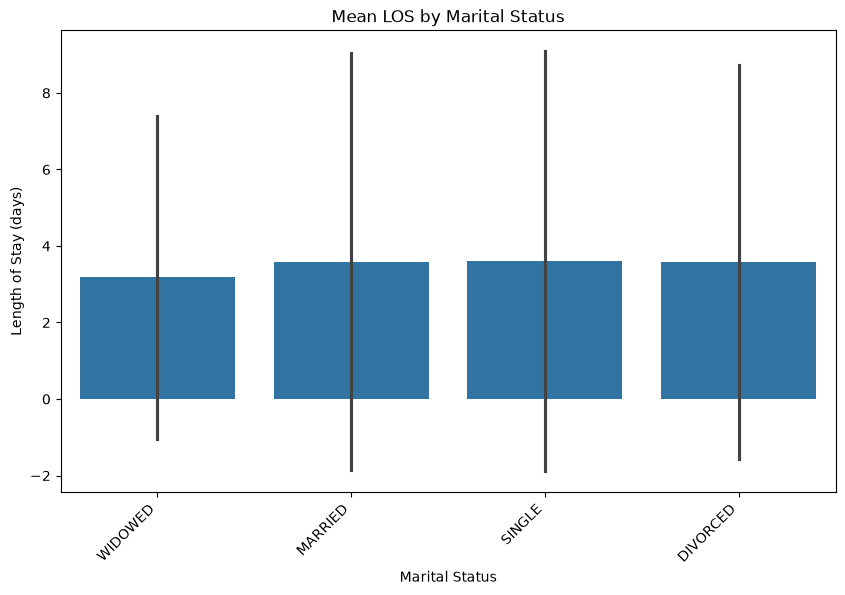

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='marital_status', y='los', errorbar='sd')
plt.title('Mean LOS by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.groupby('marital_status')['los'].mean().sort_values(ascending=False)

# Widowed individuals seem to stay the shortest by a huge margin, while divorced individuals stay the longest. 
# This could be due to various factors, including social support systems, health conditions, and access to care. 
# Further analysis would be needed to understand the underlying reasons for these differences in length of stay based on marital status.

marital_status
SINGLE      3.594429
MARRIED     3.593833
DIVORCED    3.577894
WIDOWED     3.179075
Name: los, dtype: float64

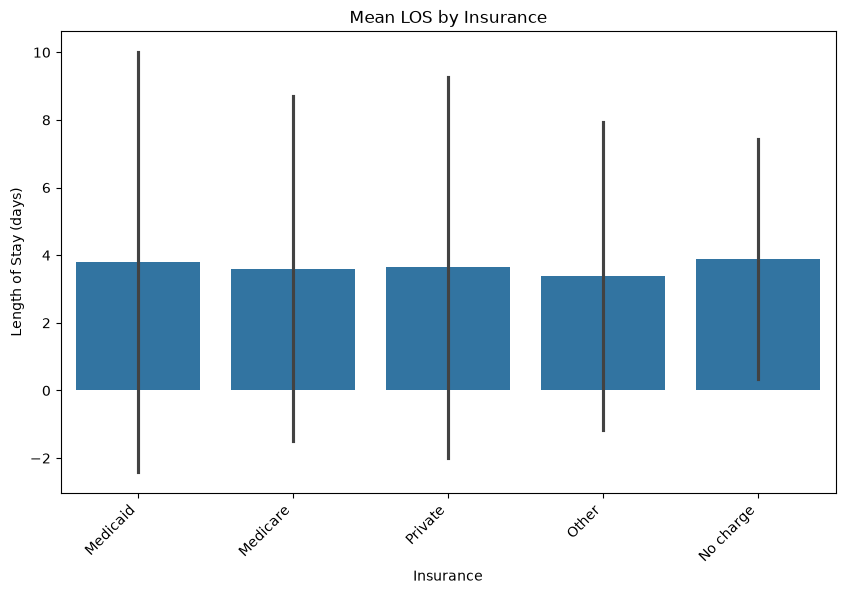

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='insurance', y='los', errorbar='sd')
plt.title('Mean LOS by Insurance')
plt.xlabel('Insurance')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.groupby('insurance')['los'].mean().sort_values(ascending=False)

# Those with no charge stay the longest, which could be due to various factors such as the severity of their conditions, lack of insurance leading to delayed care, 
# or other socioeconomic factors. Further analysis would be needed to understand the underlying reasons for these differences in length of stay based on insurance type.

insurance
No charge    3.874593
Medicaid     3.791910
Private      3.639239
Medicare     3.604113
Other        3.393845
Name: los, dtype: float64

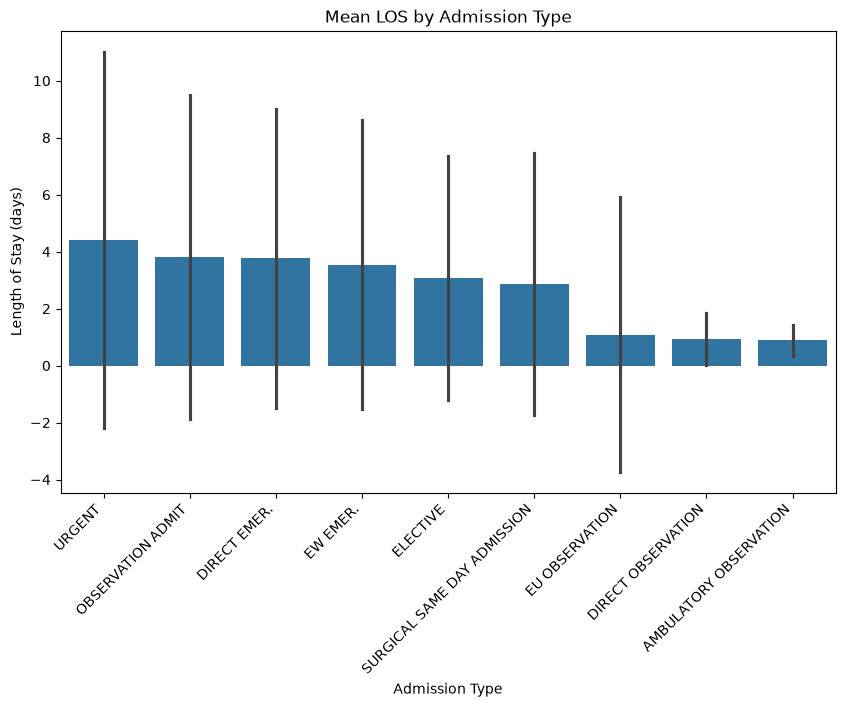

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='admission_type', y='los', errorbar='sd', order=df.groupby('admission_type')['los'].mean().sort_values(ascending=False).index)
plt.title('Mean LOS by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [55]:
df.groupby('admission_type')['los'].mean().sort_values(ascending=False)

# Describes why the patient is there and the severity, very abstract to me right now but intuitively those in urgent care stay the longest by far

admission_type
URGENT                         4.407848
OBSERVATION ADMIT              3.824740
DIRECT EMER.                   3.769731
EW EMER.                       3.543752
ELECTIVE                       3.088629
SURGICAL SAME DAY ADMISSION    2.869612
EU OBSERVATION                 1.085947
DIRECT OBSERVATION             0.924400
AMBULATORY OBSERVATION         0.886184
Name: los, dtype: float64

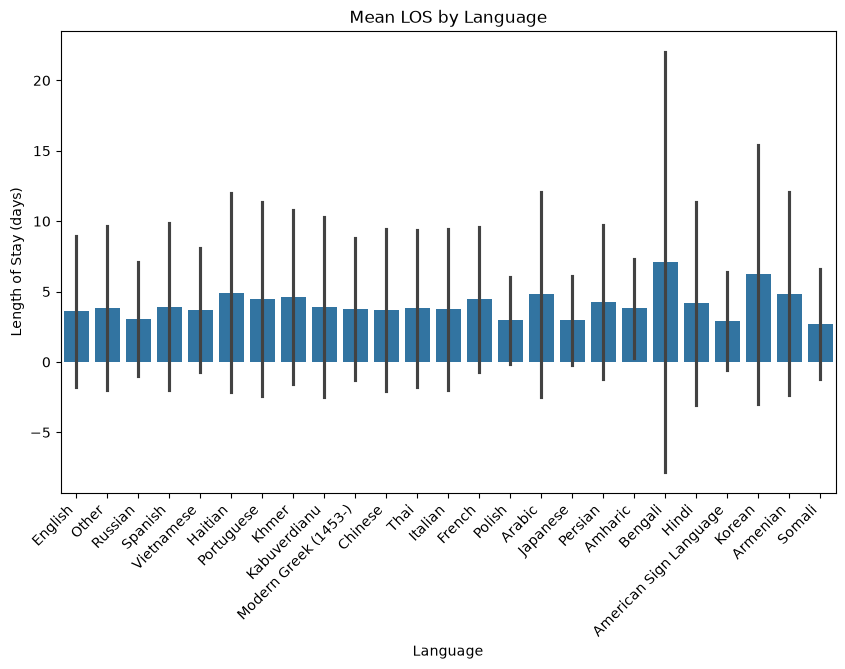

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='language', y='los', errorbar='sd')
plt.title('Mean LOS by Language')
plt.xlabel('Language')
plt.ylabel('Length of Stay (days)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
df.groupby('language')['los'].mean().sort_values(ascending=False)

# Highest variance is Bengali and highest mean, while Somali is lowest
# I wonder why there is so much variance in the languages when it comes to LOS. It could be due to various factors such as cultural differences, 
# access to healthcare, socioeconomic status, or other underlying health conditions. Further analysis would be needed to understand the reasons 
# behind these differences in length of stay based on language.

language
Bengali                   7.092401
Korean                    6.223909
Haitian                   4.918890
Armenian                  4.859551
Arabic                    4.811911
Khmer                     4.626540
Portuguese                4.485786
French                    4.458803
Persian                   4.249031
Hindi                     4.155413
Spanish                   3.935498
Kabuverdianu              3.897959
Other                     3.823010
Thai                      3.810232
Amharic                   3.802098
Modern Greek (1453-)      3.758326
Italian                   3.740794
Chinese                   3.705898
Vietnamese                3.659918
English                   3.596790
Russian                   3.078117
Japanese                  2.963713
Polish                    2.954031
American Sign Language    2.883554
Somali                    2.701465
Name: los, dtype: float64

Here's the full walkthrough of notebooks/real eda.ipynb, cell by cell, with the markdown notes (your own commentary) called out:




1. Data loading (code) — Loaded admissions, patients, icustays from MIMIC-IV. Shapes: 546,028 / 364,627 / 94,458 rows.




2. Markdown note:

> "Was expecting a 1:1:1 ratio between the rows in the columns (i.e: one patient per column but that's clearly not the case)"




→ Key finding: the three tables are not patient-level 1:1:1. patients (364,627) < admissions (546,028) means patients have multiple hospital admissions on average (~1.5x). icustays (94,458) is much smaller than admissions, meaning most hospital admissions never go to the ICU — only about 17% of admissions have an associated ICU stay. This is a structural fact that governs how you'll need to join/aggregate later (one patient → many admissions → zero or more ICU stays).




3. .head() display of all three tables (code) — confirmed column contents: admissions has admit/discharge times, admission type/location, demographics (insurance, language, marital status, race), death flag; patients has gender, age, anchor year, date of death; icustays has care unit, in/out times, and los.




4. Markdown note:

> "Join key: subject_id column"




→ Established subject_id as the linking key across all three tables (with hadm_id as the secondary key between admissions and icustays).




5. Markdown note — project goals:

> Goal

> - Predict LOS (length of stay in days)

> - Readmission risk (Bern: Will they come back in 30 days? Probability?)




→ This is the actual project scope statement: two modeling targets — (1) a regression on ICU length of stay, (2) a binary/Bernoulli classification (with probability output) for 30-day readmission.




6. Markdown note:

> "los column is given to us in icustays table: but what is the unit of time? I am taking an educated guess that it is in days. Plot los to get an idea of distribution type"




→ Flags an actual data-documentation gap — the unit of los isn't explicit in-notebook, and you're inferring "days" rather than confirming it from a data dictionary. Worth locking down before modeling (MIMIC-IV's official docs do confirm los is in days, fractional, computed from ICU in/out time — so your assumption is correct, but the notebook itself treats it as unverified).




7. Histogram (code) — plotted los distribution, 50 bins, range 0–50 days.




8. Markdown note:

> "LOS looks like it follows an exponential distribution."




→ Confirmed numerically (from the follow-up analysis I ran): mean 3.63 days vs. median 1.97 days, std 5.40, max 226.4 days, with 99% of stays under 26.4 days — classic right-skewed/exponential-like shape, validating your visual read.




9. Empty trailing cell — notebook stops here; no readmission-window logic, no merge of the three tables, and no missing-data audit yet (e.g., admissions has NaNs in deathtime, admission_location, discharge_location, insurance, language).




Overall state: exploration has established the join structure and confirmed the LOS target's distribution, but the two stated goals (LOS regression, 30-day readmission classification) have no modeling or even table-merging work started yet.

In [59]:
import pickle

with open('mimic_merged_eda.pkl', 'wb') as f:
    pickle.dump(df, f)

In [1]:
# Load back later

import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

with open('mimic_merged_eda.pkl', 'rb') as f:
    df = pickle.load(f)


df.to_pickle('mimic_merged_eda.pkl')
# and later:
df = pd.read_pickle('mimic_merged_eda.pkl')

In [2]:
df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,admittime,dischtime,...,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,anchor_year_group,dod,race_simple
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,...,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0,F,52,2180,2014 - 2016,2180-09-09,White
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,...,WHITE,2150-11-02 11:41:00,2150-11-02 19:37:00,0,F,86,2150,2008 - 2010,2152-01-30,White
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,...,BLACK/AFRICAN AMERICAN,2189-06-27 06:25:00,2189-06-27 08:42:00,0,F,73,2186,2008 - 2010,2193-08-26,Black
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,...,WHITE,2157-11-18 17:38:00,2157-11-19 01:24:00,0,F,55,2157,2011 - 2013,NaN,White
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,...,WHITE,NaN,NaN,0,F,55,2157,2011 - 2013,NaN,White


* * Feature Engineering / XGBoost Preparation 

In [64]:
result = df.columns.tolist()

for result in df:
    print(result + ": " + str(df[result].dtype))

subject_id: int64
hadm_id: int64
stay_id: int64
first_careunit: str
last_careunit: str
intime: str
outtime: str
los: float64
admittime: str
dischtime: str
deathtime: str
admission_type: str
admit_provider_id: str
admission_location: str
discharge_location: str
insurance: str
language: str
marital_status: str
race: str
edregtime: str
edouttime: str
hospital_expire_flag: int64
gender: str
anchor_age: int64
anchor_year: int64
anchor_year_group: str
dod: str
race_simple: str


In [ ]:
# see unique value counts for every categorical column, in one loop
for col in df.select_dtypes(include='object').columns:
    print(f"\n--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts().head(10))

# which columns are low-cardinality (safe to one-hot) versus high-cardinality
# Turn these columns into categorical variables for modeling, and one-hot encode the low-cardinality ones. For high-cardinality ones, consider using embeddings or other techniques.
# XGBoost wants numeric values


--- first_careunit (17 unique values) ---
first_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                            10775
Trauma SICU (TSICU)                                 10474
Neuro Intermediate                                   5776
Neuro Surgical Intensive Care Unit (Neuro SICU)      1751
Neuro Stepdown                                       1421
Surgery/Vascular/Intermediate                         145
Name: count, dtype: int64

--- last_careunit (17 unique values) ---
last_careunit
Medical Intensive Care Unit (MICU)                  20703
Medical/Surgical Intensive Care Unit (MICU/SICU)    15449
Cardiac Vascular Intensive Care Unit (CVICU)        14771
Surgical Intensive Care Unit (SICU)                 13009
Coronary Care Unit (CCU)                        

C:\Users\icsti\AppData\Local\Temp\ipykernel_23476\2928953756.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [3]:
onehot_cols = ['admission_type', 'admission_location', 'insurance', 
               'marital_status', 'race_simple', 'first_careunit']

df_encoded = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# gender: just 2 categories, simpler to binary-map than one-hot
df_encoded['gender_binary'] = (df_encoded['gender'] == 'M').astype(int)

df_encoded.head()

,subject_id,hadm_id,stay_id,last_careunit,intime,outtime,los,admittime,dischtime,deathtime,...,first_careunit_Neuro Intermediate,first_careunit_Neuro Stepdown,first_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU),first_careunit_Neurology,first_careunit_PACU,first_careunit_Surgery/Trauma,first_careunit_Surgery/Vascular/Intermediate,first_careunit_Surgical Intensive Care Unit (SICU),first_careunit_Trauma SICU (TSICU),gender_binary
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,...,False,False,False,False,False,False,False,False,False,0
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,2150-11-02 18:02:00,2150-11-12 13:45:00,NaN,...,False,False,False,False,False,False,False,False,False,0
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,2189-06-27 07:38:00,2189-07-03 03:00:00,NaN,...,False,False,False,False,False,False,False,False,False,0
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,2157-11-18 22:56:00,2157-11-25 18:00:00,NaN,...,False,False,False,False,False,False,False,True,False,0
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,2157-12-18 16:58:00,2157-12-24 14:55:00,NaN,...,False,False,False,False,False,False,False,True,False,0


In [8]:
df_encoded['gender'].value_counts()

gender
M    52875
F    41583
Name: count, dtype: int64

In [ ]:
df_encoded['gender_binary'].value_counts()
# 1: Male
# 2: Female


gender_binary
1    52875
0    41583
Name: count, dtype: int64

 Average admit hour: 12.57
 Average admit hour: 14.00


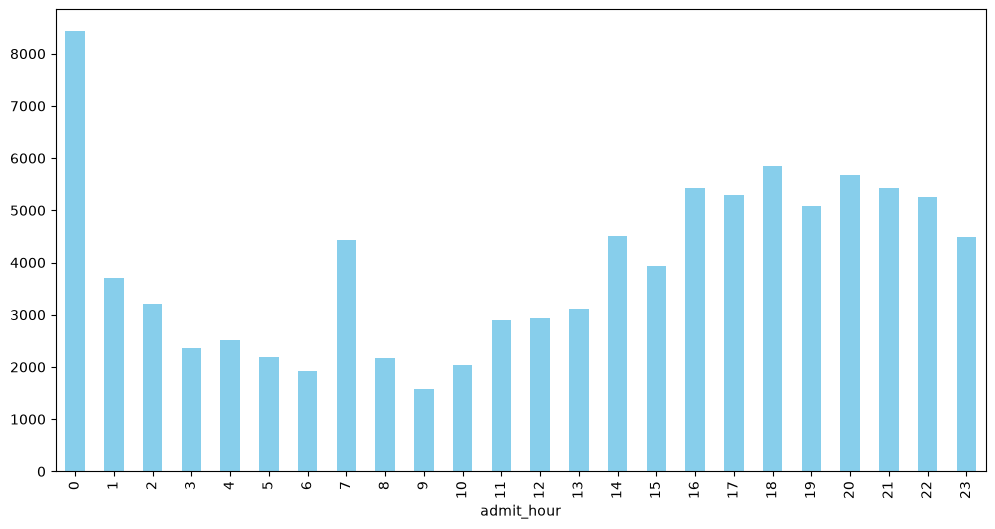

In [ ]:
# Hour of admission transformation to 24 hours

df_encoded['admit_hour'] = pd.to_datetime(df_encoded['admittime']).dt.hour

df_encoded['admit_hour'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6), color='skyblue')

print(f' Average admit hour: {df_encoded["admit_hour"].mean():.2f}')
print(f' Average admit hour: {df_encoded["admit_hour"].median():.2f}')

# So, around 12:57 P.M. Average
# 2 P.M for median (sligt skew)

 Average admit day of week: 3.00
 Average admit day of week: 3.00


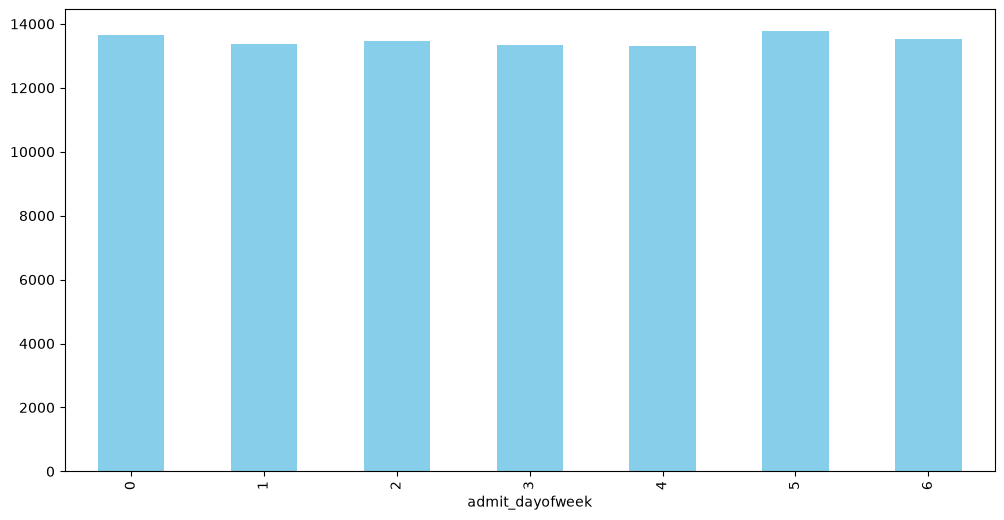

In [ ]:
df_encoded['admit_dayofweek'] = pd.to_datetime(df_encoded['admittime']).dt.dayofweek

df_encoded['admit_dayofweek'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6), color='skyblue')

print(f' Average admit day of week: {df_encoded["admit_dayofweek"].mean():.2f}')
print(f' Average admit day of week: {df_encoded["admit_dayofweek"].median():.2f}')

# 1/n for all days


 Average ED duration: 6.38 hours
 Median ED duration: 5.25 hours


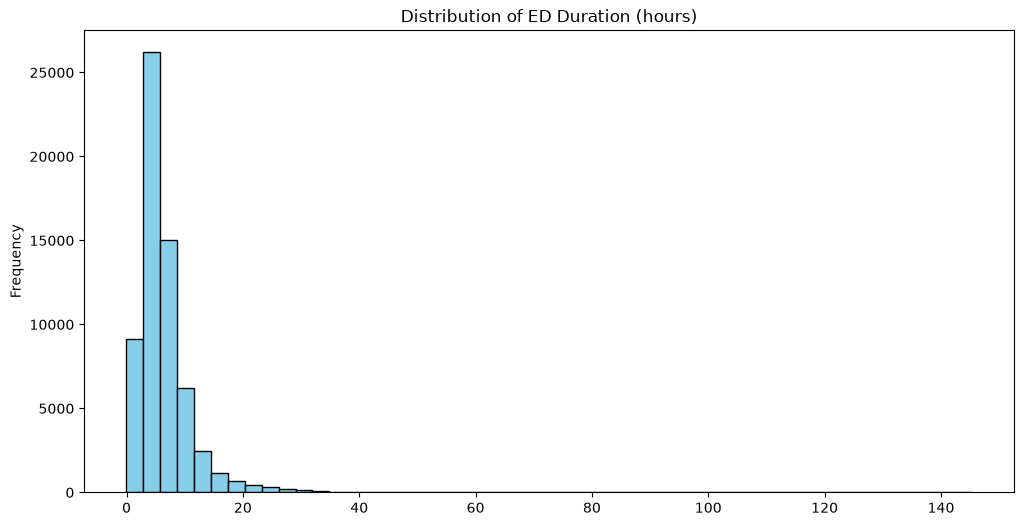

In [13]:
# Duration:

df_encoded['ed_duration_hours'] = (pd.to_datetime(df_encoded['edouttime']) - pd.to_datetime(df_encoded['edregtime'])).dt.total_seconds() / 3600

df_encoded['ed_duration_hours'].plot(kind='hist', bins=50, figsize=(12, 6), color='skyblue', edgecolor='black')
plt.title('Distribution of ED Duration (hours)')

print(f' Average ED duration: {df_encoded["ed_duration_hours"].mean():.2f} hours')
print(f' Median ED duration: {df_encoded["ed_duration_hours"].median():.2f} hours')

In [15]:
import os
print(os.getcwd())

e:\MedAgent\notebooks


In [19]:
df_encoded.to_pickle('mimic_encoded_features.pkl')

In [ ]:
import pandas as pd
df_encoded = pd.read_pickle('mimic_encoded_features.pkl')




df_encoded.to_pickle(r'E:\MedAgent\mimic_encoded_features.pkl')
# and later:
df_encoded = pd.read_pickle(r'E:\MedAgent\mimic_encoded_features.pkl')

In [1]:
import pandas as pd
df_encoded = pd.read_pickle('mimic_encoded_features.pkl')

# run next

In [17]:
os.listdir()

['demo eda.ipynb', 'mimic_merged_eda.pkl', 'real eda.ipynb']

In [9]:
df_encoded.head(1)

,subject_id,hadm_id,stay_id,last_careunit,intime,outtime,los,admittime,dischtime,deathtime,...,first_careunit_Neurology,first_careunit_PACU,first_careunit_Surgery/Trauma,first_careunit_Surgery/Vascular/Intermediate,first_careunit_Surgical Intensive Care Unit (SICU),first_careunit_Trauma SICU (TSICU),gender_binary,admit_hour,admit_dayofweek,ed_duration_hours
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,...,False,False,False,False,False,False,0,12,6,8.1


In [8]:
i=0
for column in df_encoded.columns:
    i+= 1
    print(f"{i} {column}: {df_encoded[column].iloc[0]}")
    

1 subject_id: 10000032
2 hadm_id: 29079034
3 stay_id: 39553978
4 last_careunit: Medical Intensive Care Unit (MICU)
5 intime: 2180-07-23 14:00:00
6 outtime: 2180-07-23 23:50:47
7 los: 0.4102662037037037
8 admittime: 2180-07-23 12:35:00
9 dischtime: 2180-07-25 17:55:00
10 deathtime: nan
11 admit_provider_id: P06OTX
12 discharge_location: HOME
13 language: English
14 race: WHITE
15 edregtime: 2180-07-23 05:54:00
16 edouttime: 2180-07-23 14:00:00
17 hospital_expire_flag: 0
18 gender: F
19 anchor_age: 52
20 anchor_year: 2180
21 anchor_year_group: 2014 - 2016
22 dod: 2180-09-09
23 admission_type_DIRECT EMER.: False
24 admission_type_DIRECT OBSERVATION: False
25 admission_type_ELECTIVE: False
26 admission_type_EU OBSERVATION: False
27 admission_type_EW EMER.: True
28 admission_type_OBSERVATION ADMIT: False
29 admission_type_SURGICAL SAME DAY ADMISSION: False
30 admission_type_URGENT: False
31 admission_location_CLINIC REFERRAL: False
32 admission_location_EMERGENCY ROOM: True
33 admission_loc

* To Drop:

Drop IDs/ raw text / leakage

In [10]:
drop_cols = ['subject_id', 'hadm_id', 'stay_id', 'last_careunit', 'discharge_location',
             'language', 'race', 'admit_provider_id', 'gender',
             'intime', 'outtime', 'admittime', 'dischtime', 'deathtime', 'dod',
             'edregtime', 'edouttime', 'anchor_year', 'anchor_year_group',
             'hospital_expire_flag']

model_df = df_encoded.drop(columns=drop_cols)
model_df.iloc[0]

los                                                                0.410266
anchor_age                                                               52
admission_type_DIRECT EMER.                                           False
admission_type_DIRECT OBSERVATION                                     False
admission_type_ELECTIVE                                               False
admission_type_EU OBSERVATION                                         False
admission_type_EW EMER.                                                True
admission_type_OBSERVATION ADMIT                                      False
admission_type_SURGICAL SAME DAY ADMISSION                            False
admission_type_URGENT                                                 False
admission_location_CLINIC REFERRAL                                    False
admission_location_EMERGENCY ROOM                                      True
admission_location_INFORMATION NOT AVAILABLE                          False
admission_lo

In [ ]:
# convert booleans to int

bool_cols =model_df.select_dtypes(include='bool').columns
model_df[bool_cols] = model_df[bool_cols].astype(int)

model_df.iloc[0]

# False: 0
# True: 1

los                                                                 0.410266
anchor_age                                                         52.000000
admission_type_DIRECT EMER.                                         0.000000
admission_type_DIRECT OBSERVATION                                   0.000000
admission_type_ELECTIVE                                             0.000000
admission_type_EU OBSERVATION                                       0.000000
admission_type_EW EMER.                                             1.000000
admission_type_OBSERVATION ADMIT                                    0.000000
admission_type_SURGICAL SAME DAY ADMISSION                          0.000000
admission_type_URGENT                                               0.000000
admission_location_CLINIC REFERRAL                                  0.000000
admission_location_EMERGENCY ROOM                                   1.000000
admission_location_INFORMATION NOT AVAILABLE                        0.000000

In [20]:
bad_mask = model_df['los'].isna() | np.isinf(model_df['los'])

print(f'dropped rows: {bad_mask.sum()} out of {len(model_df)}')

model_df = model_df[~bad_mask]


X = model_df.drop(columns=['los'])
y = model_df['los']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dropped rows: 14 out of 94458


In [16]:
import numpy as np

print(y_train.isna().sum())
print(np.isinf(y_train).sum())
print(y_train.describe())

12
0
count    75554.000000
mean         3.624041
std          5.344052
min          0.001250
25%          1.096597
50%          1.966858
75%          3.868041
max        226.403079
Name: los, dtype: float64


In [22]:
import xgboost as xgb 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


model = xgb.XGBRegressor( n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# n estimators = number of trees
# max depth = maximum depth of each tree
# learning rate = step size shrinkage used to prevent overfitting
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)    
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 27.2159
Root Mean Squared Error (RMSE): 5.2169
R-squared (R2): 0.0425


RMSE: off by 5.2 days

Need to fix model_df

In [27]:
i=0

for column in model_df.columns:
    i+= 1
    print(f"{i} {column}: {model_df[column].iloc[0]} - data type: {model_df[column].dtype}")

1 los: 0.4102662037037037 - data type: float64
2 anchor_age: 52 - data type: int64
3 admission_type_DIRECT EMER.: 0 - data type: int64
4 admission_type_DIRECT OBSERVATION: 0 - data type: int64
5 admission_type_ELECTIVE: 0 - data type: int64
6 admission_type_EU OBSERVATION: 0 - data type: int64
7 admission_type_EW EMER.: 1 - data type: int64
8 admission_type_OBSERVATION ADMIT: 0 - data type: int64
9 admission_type_SURGICAL SAME DAY ADMISSION: 0 - data type: int64
10 admission_type_URGENT: 0 - data type: int64
11 admission_location_CLINIC REFERRAL: 0 - data type: int64
12 admission_location_EMERGENCY ROOM: 1 - data type: int64
13 admission_location_INFORMATION NOT AVAILABLE: 0 - data type: int64
14 admission_location_INTERNAL TRANSFER TO OR FROM PSYCH: 0 - data type: int64
15 admission_location_PACU: 0 - data type: int64
16 admission_location_PHYSICIAN REFERRAL: 0 - data type: int64
17 admission_location_PROCEDURE SITE: 0 - data type: int64
18 admission_location_TRANSFER FROM HOSPITAL: 0

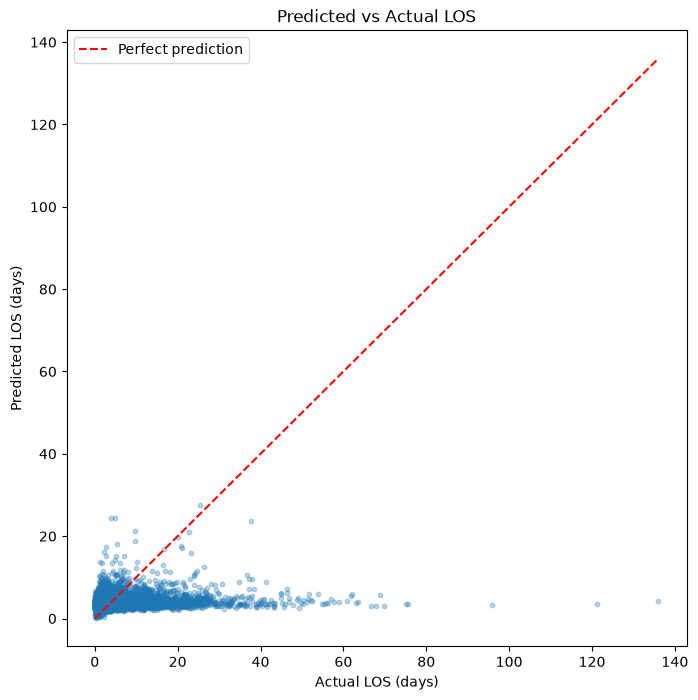

In [25]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual LOS (days)')
plt.ylabel('Predicted LOS (days)')
plt.title('Predicted vs Actual LOS')
plt.legend()
plt.show()

# Prediction vs actual plot

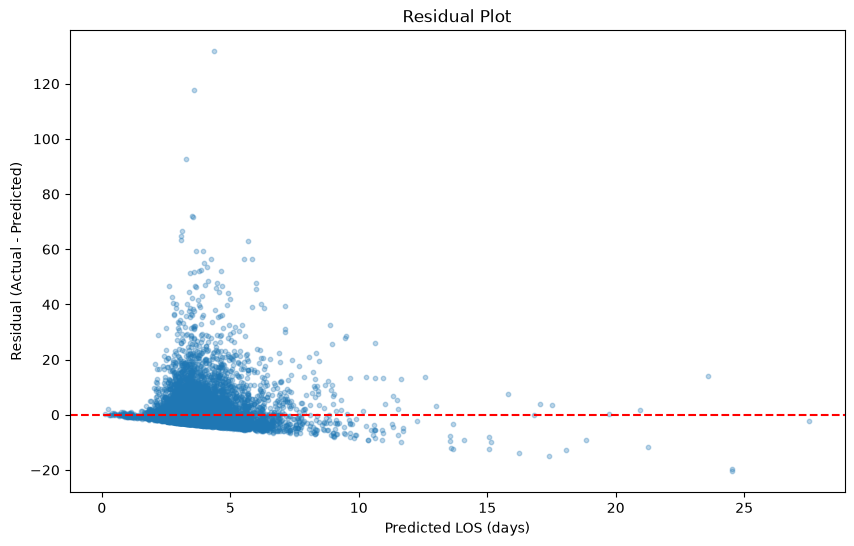

In [26]:
#plot residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted LOS (days)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [29]:
for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame):
        print(name, val.shape)

___ (1, 72)
df_encoded (94458, 72)
_3 (5, 72)
_9 (1, 72)
model_df (94444, 52)
X (94444, 51)
X_train (75555, 51)
X_test (18889, 51)


In [33]:
import os
print(os.listdir('E:/mimic-iv/hosp'))
print(os.listdir('E:/mimic-iv/icu'))

['admissions.csv.gz', 'patients.csv.gz']
['icustays.csv.gz']
